# Japan IDWR — Prefecture-level Weekly Infectious Disease Surveillance

This notebook demonstrates the **Japan IDWR** accessor for the Infectious Diseases
Weekly Report published by the Japan Institute for Health Security (JIHS, formerly NIID).

- **Coverage:** all 47 prefectures, weekly, **2023 → present** on the current portal
- **Tables:** notifiable diseases (88), sentinel-reporting diseases (19) — weekly, weekly incl.
  delayed reports, and cumulative variants
- **Docs:** [IDWR portal](https://id-info.jihs.go.jp/en/surveillance/idwr/)

## 1. Setup and discovery

In [1]:
import pandas as pd

from epidatasets.sources.japan_idwr import JapanIDWRAccessor, JapanIDWRDataError

idwr = JapanIDWRAccessor()  # cached on disk, TTL 24 h

print("Years:", idwr.get_available_years())
print("Latest week:", idwr.get_latest_week())

Years: [2023, 2024, 2025, 2026]
Latest week: (2026, 32)


## 2. The latest weekly report

In [2]:
year, week = idwr.get_latest_week()
report = idwr.get_week(year, week)
report

INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_zensu32.csv


INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_teiten32.csv


INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_teitenari32.csv


INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_teitenrui32.csv


WeeklyReport(year=2026, week=32, as_of=2026-08-12)

In [3]:
nd = report.notifiable_diseases
print(f"Notifiable: {nd['disease'].nunique()} diseases x {nd['prefecture'].nunique()} prefectures")
nd.head()

Notifiable: 88 diseases x 47 prefectures


,prefecture,disease,current_week,cumulative
0,Hokkaido,Ebola hemorrhagic fever,0,0
1,Hokkaido,Crimean-Congo hemorrhagic fever,0,0
2,Hokkaido,Smallpox,0,0
3,Hokkaido,South American hemorrhagic fever,0,0
4,Hokkaido,Plague,0,0


### Sentinel-reporting diseases (weekly)

Cases and cases-per-sentinel (e.g. pediatric sentinel clinics) — influenza, RSV,
chickenpox, HFMD, mumps, COVID-19, ...

In [4]:
sd = report.sentinel_diseases
print(f"Sentinel: {sd['disease'].nunique()} diseases x {sd['prefecture'].nunique()} prefectures")
sd.head()

Sentinel: 19 diseases x 47 prefectures


,prefecture,disease,current_week,per_sentinel
0,Hokkaido,Influenza(excld. avian influenza and pandemic ...,53.0,0.33
1,Hokkaido,Respiratory syncytial virus infection,13.0,0.14
2,Hokkaido,Pharyngoconjunctival fever,35.0,0.37
3,Hokkaido,Group A streptococcal pharyngitis,167.0,1.78
4,Hokkaido,Infectious gastroenteritis,160.0,1.70


### National totals

The "Total No." row is exposed separately for every table.

In [5]:
pd.DataFrame(report.national_totals['notifiable']).T.head(10)

,disease,current_week,cumulative
Ebola hemorrhagic fever,Ebola hemorrhagic fever,0,0
Crimean-Congo hemorrhagic fever,Crimean-Congo hemorrhagic fever,0,0
Smallpox,Smallpox,0,0
South American hemorrhagic fever,South American hemorrhagic fever,0,0
Plague,Plague,0,0
Marburg disease,Marburg disease,0,0
Lassa fever,Lassa fever,0,0
Acute poliomyelitis,Acute poliomyelitis,0,0
Tuberculosis,Tuberculosis,249,8902
Diphtheria,Diphtheria,0,0


## 3. Top notifiable diseases this week (national)

Current-week cases summed over prefectures.

<Axes: title={'center': 'IDWR notifiable diseases — 2026-W32'}, ylabel='disease'>

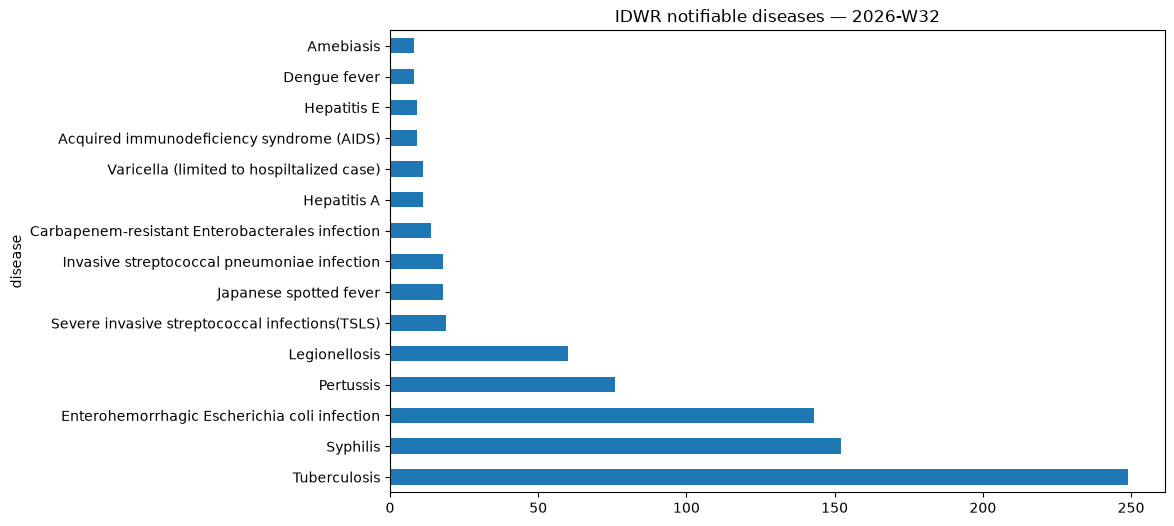

In [6]:
top = (
    nd.groupby('disease')['current_week'].sum()
    .sort_values(ascending=False)
    .head(15)
)
top.plot(kind='barh', figsize=(10, 6), title=f'IDWR notifiable diseases — {year}-W{week}')

## 4. Disease aliases

Common names resolve to the official CSV headers; unknown names are matched
case-insensitively against the table contents.

In [7]:
for alias in ['flu', 'rsv', 'HFMD', 'whooping cough', 'fifth disease', 'covid19']:
    print(f"{alias:>15} -> {idwr.resolve_disease(alias)}")

            flu -> Influenza(excld. avian influenza and pandemic influenza)
            rsv -> Respiratory syncytial virus infection
           HFMD -> Hand, foot and mouth disease
 whooping cough -> Pertussis
  fifth disease -> Erythema infection
        covid19 -> COVID-19


## 5. Disease time series across weeks

Weekly measles reports for the last 8 published weeks, nationally.

INFO:epidatasets.sources.japan_idwr:Fetching https://id-info.jihs.go.jp/en/surveillance/idwr/rapid/2026/25/zensu25.csv (attempt 1/3)


INFO:epidatasets.sources.japan_idwr:Fetching https://id-info.jihs.go.jp/en/surveillance/idwr/rapid/2026/26/zensu26.csv (attempt 1/3)


INFO:epidatasets.sources.japan_idwr:Fetching https://id-info.jihs.go.jp/en/surveillance/idwr/rapid/2026/27/zensu27.csv (attempt 1/3)


INFO:epidatasets.sources.japan_idwr:Fetching https://id-info.jihs.go.jp/en/surveillance/idwr/rapid/2026/28/zensu28.csv (attempt 1/3)


INFO:epidatasets.sources.japan_idwr:Fetching https://id-info.jihs.go.jp/en/surveillance/idwr/rapid/2026/29/zensu29.csv (attempt 1/3)


INFO:epidatasets.sources.japan_idwr:Fetching https://id-info.jihs.go.jp/en/surveillance/idwr/rapid/2026/30/zensu30.csv (attempt 1/3)


INFO:epidatasets.sources.japan_idwr:Fetching https://id-info.jihs.go.jp/en/surveillance/idwr/rapid/2026/31/zensu31.csv (attempt 1/3)


INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_zensu32.csv


<Axes: title={'center': 'Measles — national weekly cases (last 8 weeks)'}, xlabel='week'>

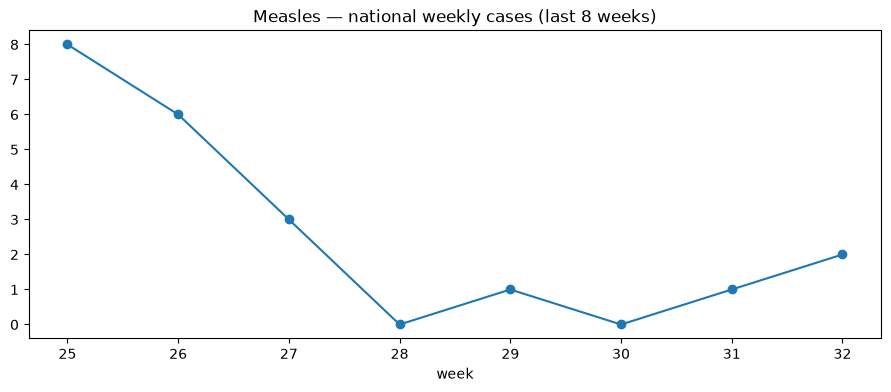

In [8]:
start = max(1, week - 7)
measles = idwr.get_disease_series(
    'measles',
    start_year=year, start_week=start,
    end_year=year, end_week=week,
)
national = measles.groupby('week')['current_week'].sum()
national.plot(figsize=(11, 4), marker='o', title='Measles — national weekly cases (last 8 weeks)')

## 6. Prefecture snapshot

All tables filtered to a single prefecture (case-insensitive).

In [9]:
tokyo = idwr.get_by_prefecture('Tokyo', year, week)
tokyo.sentinel_diseases[['disease', 'current_week', 'per_sentinel']]

INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_zensu32.csv


INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_teiten32.csv


INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_teitenari32.csv


INFO:epidatasets.sources.japan_idwr:Loading cached data: /home/fccoelho/.cache/epidatasets/japan_idwr/https___id-info.jihs.go.jp_en_surveillance_idwr_rapid_2026_32_teitenrui32.csv


,disease,current_week,per_sentinel
228,Influenza(excld. avian influenza and pandemic ...,336.0,0.84
229,Respiratory syncytial virus infection,157.0,0.63
230,Pharyngoconjunctival fever,41.0,0.16
231,Group A streptococcal pharyngitis,183.0,0.73
232,Infectious gastroenteritis,959.0,3.85
233,Chickenpox,45.0,0.18
234,"Hand, foot and mouth disease",923.0,3.71
235,Erythema infection,7.0,0.03
236,Exanthem subitum,73.0,0.29
237,Herpangina,259.0,1.04


## 7. Sentinel per-sentinel intensity by prefecture

Influenza cases per sentinel in the latest week — comparable across prefectures.

<Axes: title={'center': 'Influenza cases per sentinel by prefecture — 2026-W32'}, xlabel='prefecture'>

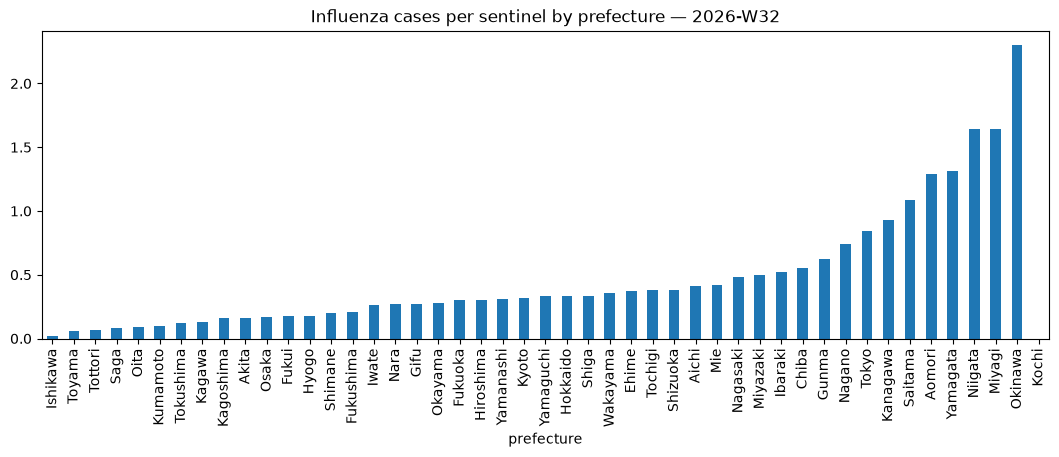

In [10]:
flu = report.sentinel_diseases[
    report.sentinel_diseases['disease'].str.startswith('Influenza')
]
flu.set_index('prefecture')['per_sentinel'].sort_values().plot(
    kind='bar', figsize=(13, 4),
    title=f'Influenza cases per sentinel by prefecture — {year}-W{week}',
)

## 8. Error handling & caching

- Years before 2023 raise a `ValueError` (the legacy NIID archive is out of scope)
- Unpublished weeks raise `JapanIDWRDataError`
- Reports are cached on disk (TTL 24 h — data updates weekly); pass `use_cache=False` to force a refresh

In [11]:
try:
    idwr.get_week(2019, 10)
except ValueError as e:
    print(f"ValueError: {e}")

try:
    idwr.get_week(2023, 53)
except JapanIDWRDataError as e:
    print(f"JapanIDWRDataError: {str(e)[:80]}...")

INFO:epidatasets.sources.japan_idwr:Fetching https://id-info.jihs.go.jp/en/surveillance/idwr/rapid/2023/53/zensu53.csv (attempt 1/3)


ValueError: Year 2019 is before portal coverage (>= 2023). Reports from 1996-2022 live in the legacy NIID archive (https://www.niid.go.jp/niid/en/surveillance/) and are not available through this accessor.


JapanIDWRDataError: No IDWR report for 2023 week 53 (zensu): Failed to fetch https://id-info.jihs.go...


## 9. Using the registry

The accessor is also reachable through the plugin registry.

In [12]:
from epidatasets import get_source, list_sources

print('japan_idwr' in list_sources())
ds = get_source('japan_idwr')
ds.get_latest_week()

INFO:epidatasets.sources.eurostat:eurostat library not installed. Using REST API fallback.


True


(2026, 32)